In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import json
from tqdm import tqdm
import numpy as np
import healpy as hp

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [2]:
from fpp.models.np_model import NPModel
m = NPModel(data=np.zeros(hp.nside2npix(128)))
nm = m.normalization_mask

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of exposure regions: 1
Number of pixels in ROI: 6839
Using psf: king
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/analysis/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 0.0


# mixpib

In [12]:
s = pickle.load(open('../outputs/production/fits/hmc_Dmixpib_Mbase23fix/i1_n10000_ns0.p', 'rb'))
s.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pib', 'zs'])

0.352 ± 0.062
0.067 ± 0.061
0.581 ± 0.080


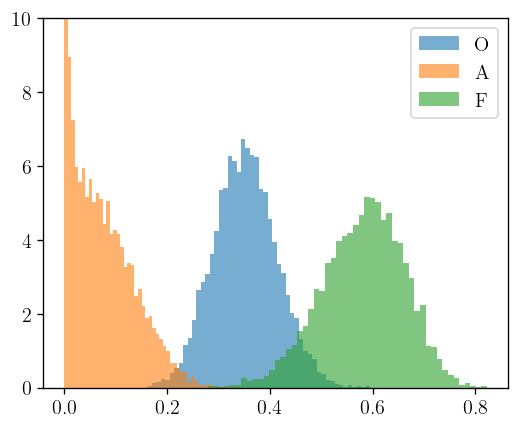

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

labels = ['O', 'A', 'F']

for i in range(3):
    z = s['theta_pib'][:, i]
    print(f'{np.mean(z):.3f} ± {np.std(z):.3f}')
    ax.hist(z, bins=50, density=True, alpha=0.6, label=labels[i])
ax.set(ylim=(0, 10))
ax.legend()

# mixpib: spherical harmonics

In [29]:
s = pickle.load(open('../outputs/production/fits/hmc_Dmixpib_Mbase23fix/i1_n10000_ns0.p', 'rb'))

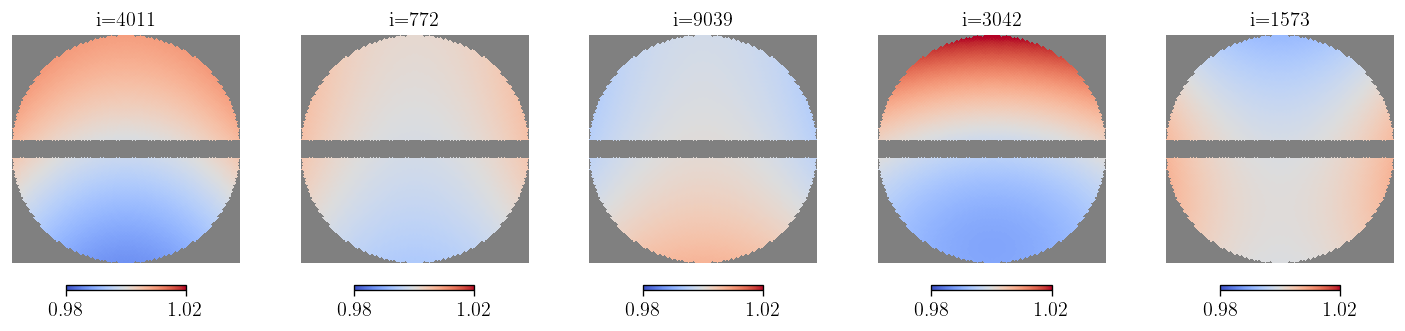

In [30]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i_sample, ax in zip(np.random.randint(10000, size=(5,)), axs):

    mod = np.ones_like(m.Ylm_temps[0])
    for i in range(6):
        mod += m.Ylm_temps[i] * s[f'Alm_{i}'][i_sample]
    mod = np.array(mod)
    mod /= np.mean(mod[~nm])
    mod[nm] = np.nan
    plt.sca(ax)
    hp.cartview(mod, lonra=[-25, 25], latra=[-25, 25], cmap='coolwarm', min=0.98, max=1.02, hold=True, title=f'i={i_sample}')

# p6v11

In [3]:
def get_diffuse(s, i, n_temps=3):
    pib = np.zeros(hp.nside2npix(128))
    ics = np.zeros(hp.nside2npix(128))
    for ii in range(n_temps):
        pib += s[f'theta_pib'][i][ii] * m.pib[ii]
        ics += s[f'theta_ics'][i][ii] * m.ics[ii]

    mod = np.ones(hp.nside2npix(128))
    for ii in range(6):
        mod += m.Ylm_temps[ii] * s[f'Alm_{ii}'][i]
    mod = np.array(mod)
    pib *= mod

    pib /= np.mean(pib[~nm])
    pib *= s['S_pib'][i]

    ics /= np.mean(ics[~nm])
    ics *= s['S_ics'][i]

    t = np.array(pib + ics)
    t[nm] = np.nan
    return t

Text(0.5, 0.98, 'P6V11 recover with OAF')

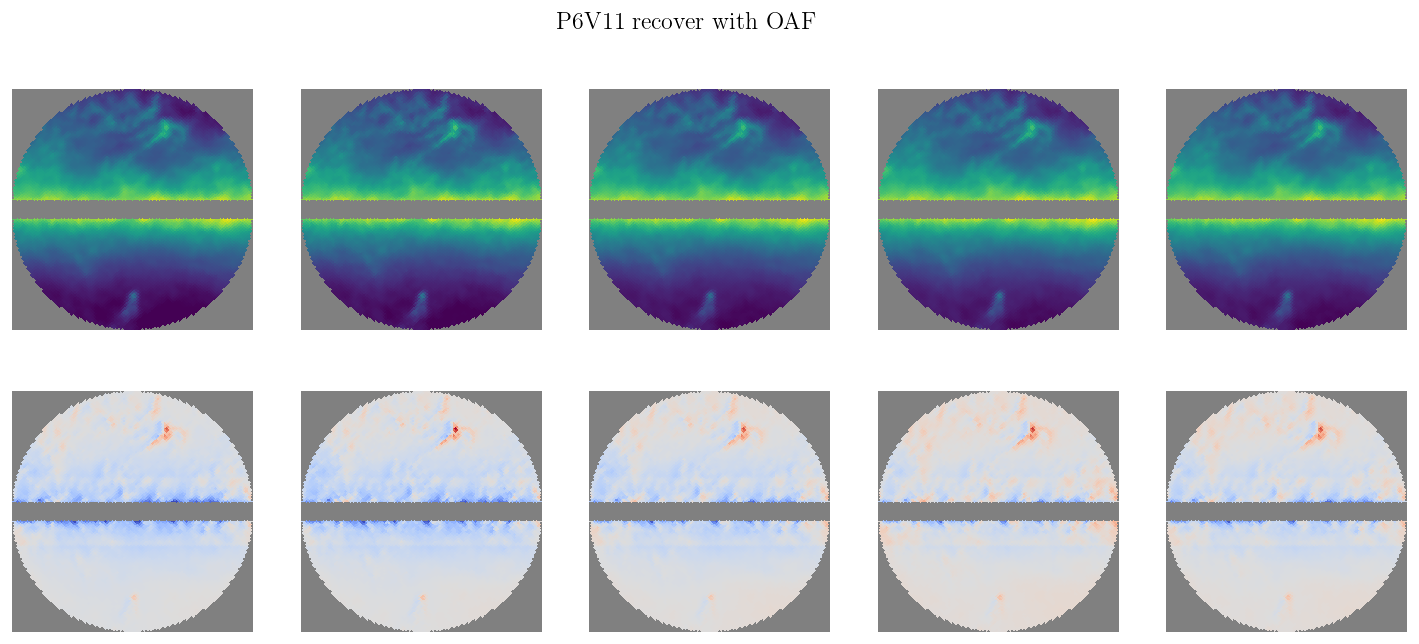

In [4]:
fn, n_temps, title = 'hmc_D23new_p6v11_Mbase23fix', 3, 'OAF'
# fn, n_temps, title = 'hmc_D23new_p6v11_Mbase23fixO', 1, 'O'


s = pickle.load(open(f'../outputs/production/fits/{fn}/i2_n10000_ns0.p', 'rb'))
Strue_p6v11 = 17.7

fig, axs = plt.subplots(2, 5, figsize=(15, 6))

for iax, i in enumerate(np.random.randint(0, 10000, 5)):
    t = get_diffuse(s, i, n_temps=n_temps)
    plt.sca(axs[0, iax])
    hp.cartview(np.log(np.clip(t, 0.5, None)), latra=[-25, 25], lonra=[-25, 25], hold=True, title='', min=1.5, max=4.5, cbar=False)

    t = t - m.temp_p6v11 * Strue_p6v11
    plt.sca(axs[1, iax])
    hp.cartview(t, latra=[-25, 25], lonra=[-25, 25], hold=True, title='', cmap='coolwarm', min=-15, max=15, cbar=False)

fig.suptitle(f'P6V11 recover with {title}')

In [6]:
data = [
    ('hmc_D23new_p6v11_Mbase23fix', 3, 'OAF'),
    ('hmc_D23new_p6v11_Mbase23fixO', 1, 'O'),
    ('hmc_D23new_p6v11_Mbase23fixA', 1, 'A'),
    ('hmc_D23new_p6v11_Mbase23fixF', 1, 'F'),
]

t_s = []
for fn, n_temps, title in data:
    Strue_p6v11 = 17.7
    s = pickle.load(open(f'../outputs/production/fits/{fn}/i2_n10000_ns0.p', 'rb'))
    n = 1000
    ts = []
    for i in tqdm(np.random.randint(0, 10000, n)):
        ts.append(get_diffuse(s, i, n_temps=n_temps))
    t = np.median(ts, axis=0)
    t -= m.temp_p6v11 * Strue_p6v11
    t_s.append(t)

100%|██████████| 1000/1000 [00:13<00:00, 75.78it/s]


In [7]:
print(np.mean(np.abs(t_s)[:, ~nm], axis=1))

[1.04507009 3.03231594 1.66058232 1.1871371 ]


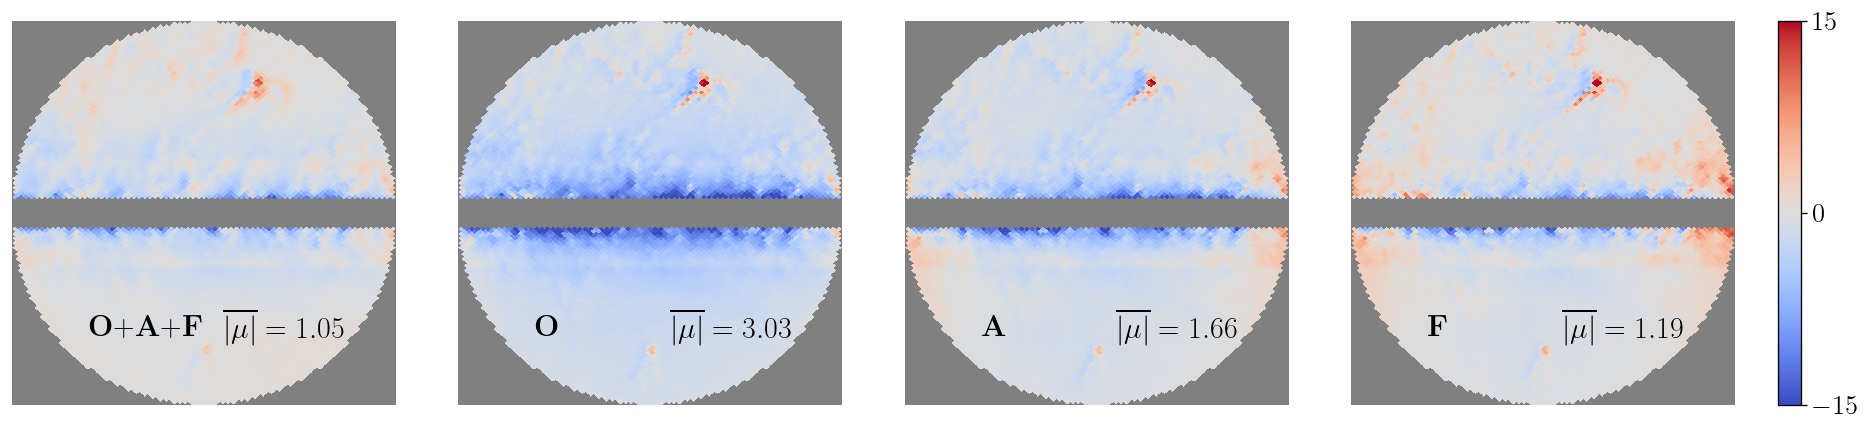

In [8]:
vmin, vmax = -15, 15
cmap = "coolwarm"
texts = [r'$\mathbf{O}$+$\mathbf{A}$+$\mathbf{F}$', r'$\mathbf{O}$', r'$\mathbf{A}$', r'$\mathbf{F}$']
scores = np.mean(np.abs(t_s)[:, ~nm], axis=1)
texts2 = [r'$\overline{|\mu|}=' + f'{score:.2f}$' for score in scores]

fig = plt.figure(figsize=(16, 4))
fig.set_layout_engine("none")  # avoid layout-engine conflicts

# ---- manual layout numbers (tweak as you like) ----
left   = 0.05
bottom = 0.12
top    = 0.92
gap    = 0.012
cbar_w = 0.012
right_pad = 0.02

H = top - bottom
W = 1.0 - left - right_pad - cbar_w - 3*gap
panel_w = W / 4.0

healpy_axes = []

for i, t in enumerate(t_s):
    x0 = left + i*(panel_w + gap)
    ax = fig.add_axes([x0, bottom, panel_w, H])
    pos = ax.get_position()  # save intended slot

    plt.sca(ax)
    hp.cartview(
        t, latra=[-25, 25], lonra=[-25, 25],
        hold=True, title=None, cmap=cmap,
        min=vmin, max=vmax, cbar=False
    )

    hax = plt.gca()          # the axes healpy actually drew into
    hax.set_position(pos)    # put it back where we want
    healpy_axes.append(hax)

    hax.text(0.2, 0.2, texts[i],
             transform=hax.transAxes,
             fontsize=18, ha='left', va='center')
    hax.text(0.55, 0.2, texts2[i],
             transform=hax.transAxes,
             fontsize=18, ha='left', va='center')

# ---- colorbar axis ----
cax_x0 = left + 4*(panel_w + gap)
cax = fig.add_axes([cax_x0, bottom, cbar_w, H])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax, orientation="vertical")
cb.set_ticks([vmin, 0, vmax])
cb.ax.tick_params(labelsize=16)
# fig.savefig("../outputs/production/plots/diffuse-diff.pdf")
